In [172]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def softmax(x):
    e_x = np.exp(x - np.max(x))  # for numerical stability
    return e_x / e_x.sum(axis=0, keepdims=True)

In [173]:
train_data = np.loadtxt("MNIST_train_1000.csv", delimiter=',').astype(int)
# Preprocess training data
X_train = (train_data[:, 1:].T / 255.0).astype(np.float32)
N_train = X_train.shape[1]
Y_train = np.zeros((10, N_train), dtype=np.float32)
labels = train_data[:, 0].astype(int)
Y_train[labels, np.arange(N_train)] = 1

# Preprocess test data
test_data = pd.read_csv('mnist_test_100.csv', header=None).values
X_test = (test_data[:, 1:].T / 255.0).astype(np.float32)
N_test = X_test.shape[1]
Y_test = np.zeros((10, N_test), dtype=np.float32)
test_labels = test_data[:, 0].astype(int)
Y_test[test_labels, np.arange(N_test)] = 1

# Initialize weights and biases
np.random.seed(42)
Ni = 784
No = 10
no_nodes = [Ni, 100, 50, No]
W = []
b = []
for i in range(1, len(no_nodes)):
    W.append(np.random.rand(no_nodes[i-1], no_nodes[i]) - 0.5)
    b.append(np.zeros((no_nodes[i], 1)))


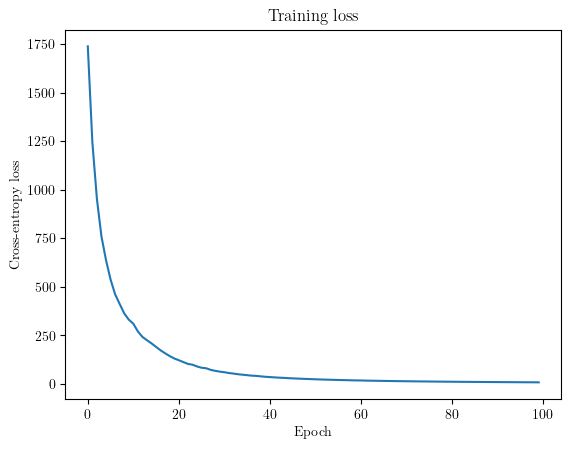

In [ ]:
# Activation functions
sig2 = lambda x: 1 / (1 + np.exp(-x))
dsig2 = lambda x: sig2(x) * (1 - sig2(x))
sig3 = softmax

# Hyperparameters
N_ep = 100
lr = 0.00965

# Plot settings
plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif"
})

# Training loop
pivec = np.zeros(N_ep)
for epoch in range(N_ep):
    mixup = np.random.permutation(N_train)
    for j in mixup:
        # Forward pass
        a1 = X_train[:, j].reshape(-1, 1)
        a = [a1]
        n = []
        for i in range(len(W) - 1):
            n.append(W[i].T @ a[i] + b[i])
            a.append(sig2(n[i]))
        n.append(W[-1].T @ a[-1] + b[-1])
        a.append(sig3(n[-1]))

        # Backpropagation
        err = Y_train[:, j].reshape(-1, 1) - a[-1]
        S = [-err]
        for i in range(len(W)-1):
            S.append(dsig2(n[-2-i]) * (W[-1-i] @ S[i]))
        
        # Update weights and biases
        for i in range(len(W)):
            W[-1-i] -= lr * (a[-2-i] @ S[i].T)
            b[-1-i] -= lr * S[i]

    # Mid-training evaluation
    if epoch % 10 == 0:
        U,S,VT = np.linalg.svd(W[1].copy())
        plt.figure(figsize=(8, 5))
        S_ordered = np.sort(S.copy())[::-1]
        print(S)
        plt.hist(S_ordered, bins=30, edgecolor='black', linewidth=0.5)
        plt.xlabel(r"Singular Values")
        plt.ylabel(r"Frequency")
        plt.title(r"Distribution of Singular Values in $W_1$")
        plt.show()
        range_s = range(len(S))

        Testing_Accuracy = []
        for j in range_s:
            sum = np.zeros(W[1].shape)   
            for i in range_s:
                if S[i] > S[j]:
                    u_i = U[:,i].reshape(-1,1)
                    vt_i = VT[i,:].reshape(-1,1)
                    # print(f"{S[i]} * \n{u_i} @ \n{vt_i.T}\n\n")
                    matrix = S[i] * u_i @ vt_i.T
                    # print("S[i] = ", S[i])
                    # print("Matrix of size ", matrix.shape)
                    sum += matrix

            W_lowrank = W.copy()
            W_lowrank[1] = sum.copy()
            test_correct =0

            # Re-evaulation
            for j in range(N_test):
                a1 = X_test[:, j].reshape(-1, 1)
                a = [a1]
                n = []
                for i in range(len(W) - 1):
                    n.append(W_lowrank[i].T @ a[i] + b[i])
                    a.append(sig2(n[i]))
                n.append(W_lowrank[-1].T @ a[-1] + b[-1])
                a.append(sig3(n[-1]))
                if np.argmax(a[-1]) == np.argmax(Y_test[:, j]):
                    test_correct += 1
                
            Testing_Accuracy.append(test_correct/N_test)

        y_value_at_x1 = Testing_Accuracy[1]
        plt.axhline(y=y_value_at_x1, color='r', linestyle='--', label=fr"Accuracy at $x=1$: {y_value_at_x1:.2f}")
        y_value_at_x2 = Testing_Accuracy[10]
        plt.axhline(y=y_value_at_x2, color='g', linestyle='--', label=fr"Accuracy at $x=10$: {y_value_at_x2:.2f}")
        plt.plot(range_s, Testing_Accuracy)
        plt.xlabel(r"Rank of $W_1$")
        plt.ylabel(r"Accuracy")
        plt.title(fr"{len(no_nodes)} Layers ($W_1$)")
        plt.legend()
        print()
        print(f"Epoch {epoch}")
        print()

    
    # Calculate performance index
    epoch_loss = 0
    for j in range(N_train):
        a1 = X_train[:, j].reshape(-1, 1)
        a = [a1]
        n = []
        for i in range(len(W) - 1):
            n.append(W[i].T @ a[i] + b[i])
            a.append(sig2(n[i]))
        n.append(W[-1].T @ a[-1] + b[-1])
        a.append(sig3(n[-1]))

        xent = -np.sum(Y_train[:, j] * np.log(a[-1].flatten() + 1e-8))
        epoch_loss += xent
    pivec[epoch] = epoch_loss

plt.figure()
plt.plot(pivec)
plt.xlabel(r'Epoch') 
plt.ylabel(r'Cross-entropy loss')
plt.title(r'Training loss')
plt.show()



In [175]:
# Preprocess test data
test_data = pd.read_csv('mnist_test_100.csv', header=None).values
X_test = (test_data[:, 1:].T / 255.0).astype(np.float32)
N_test = X_test.shape[1]
Y_test = np.zeros((10, N_test), dtype=np.float32)
test_labels = test_data[:, 0].astype(int)
Y_test[test_labels, np.arange(N_test)] = 1

# Test predictions
On = np.zeros((10, N_test))
test_correct = 0
for j in range(N_test):
    a1 = X_test[:, j].reshape(-1, 1)
    a = [a1]
    n = []
    for i in range(len(W) - 1):
        n.append(W[i].T @ a[i] + b[i])
        a.append(sig2(n[i]))
    n.append(W[-1].T @ a[-1] + b[-1])
    a.append(sig3(n[-1]))
    if np.argmax(a[-1]) == np.argmax(Y_test[:, j]):
        test_correct += 1
    print(f"Predicted: {np.argmax(a[-1])}, Actual: {np.argmax(Y_test[:, j])} \n Accuracy: {test_correct}/{j+1}={test_correct/(j+1)*100:.2f}%")

print(f"Test accuracy: {test_correct/N_test*100:.2f}%")

Predicted: 5, Actual: 3 
 Accuracy: 0/1=0.00%
Predicted: 8, Actual: 8 
 Accuracy: 1/2=50.00%
Predicted: 0, Actual: 0 
 Accuracy: 2/3=66.67%
Predicted: 5, Actual: 5 
 Accuracy: 3/4=75.00%
Predicted: 4, Actual: 4 
 Accuracy: 4/5=80.00%
Predicted: 3, Actual: 3 
 Accuracy: 5/6=83.33%
Predicted: 8, Actual: 8 
 Accuracy: 6/7=85.71%
Predicted: 3, Actual: 3 
 Accuracy: 7/8=87.50%
Predicted: 2, Actual: 2 
 Accuracy: 8/9=88.89%
Predicted: 8, Actual: 8 
 Accuracy: 9/10=90.00%
Predicted: 0, Actual: 0 
 Accuracy: 10/11=90.91%
Predicted: 0, Actual: 0 
 Accuracy: 11/12=91.67%
Predicted: 6, Actual: 6 
 Accuracy: 12/13=92.31%
Predicted: 8, Actual: 8 
 Accuracy: 13/14=92.86%
Predicted: 5, Actual: 5 
 Accuracy: 14/15=93.33%
Predicted: 7, Actual: 7 
 Accuracy: 15/16=93.75%
Predicted: 3, Actual: 3 
 Accuracy: 16/17=94.12%
Predicted: 9, Actual: 9 
 Accuracy: 17/18=94.44%
Predicted: 0, Actual: 0 
 Accuracy: 18/19=94.74%
Predicted: 2, Actual: 2 
 Accuracy: 19/20=95.00%
Predicted: 9, Actual: 9 
 Accuracy: 20/2

[7.05639082 6.78779883 6.63605412 6.37126007 6.05913428 5.85327801
 5.31632551 4.68311268 4.4114909  4.15787071 4.00835693 3.86366107
 3.82752432 3.75912384 3.61825086 3.58227877 3.44448081 3.38889561
 3.29751268 3.1770359  3.14392195 3.01133014 2.95105866 2.85344719
 2.71757503 2.67819544 2.52460159 2.49469346 2.42511    2.38638632
 2.23421899 2.17979365 2.13151122 2.10933795 2.0321502  1.95520725
 1.90370701 1.84737889 1.74460628 1.72317426 1.65671887 1.53656481
 1.49482058 1.42980157 1.37229185 1.27374665 1.22571362 1.10856226
 0.98187566 0.89456261]


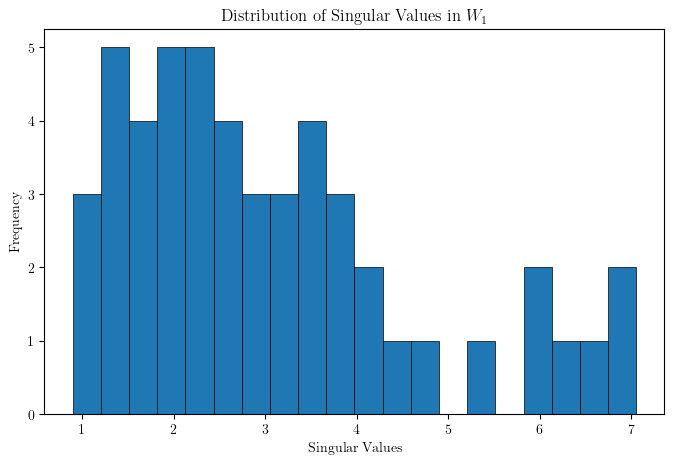

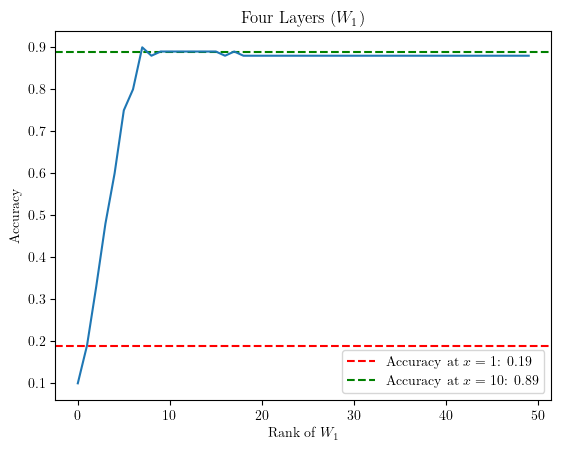

In [176]:
k=1
U,S,VT = np.linalg.svd(W[k].copy())
plt.figure(figsize=(8, 5))
S_ordered = np.sort(S.copy())[::-1]
print(S)
plt.hist(S_ordered, bins=20, edgecolor='black', linewidth=0.5)
plt.xlabel(r"Singular Values")
plt.ylabel(r"Frequency")
plt.title(fr"Distribution of Singular Values in $W_1$")
plt.show()
range_s = range(len(S))
# if len(S) > 100:
#     range_s = range(0, len(S), 3)

Testing_Accuracy = []
for j in range_s:
    sum = np.zeros(W[k].shape)   
    for i in range_s:
        if S[i] > S[j]:
            u_i = U[:,i].reshape(-1,1)
            vt_i = VT[i,:].reshape(-1,1)
            # print(f"{S[i]} * \n{u_i} @ \n{vt_i.T}\n\n")
            matrix = S[i] * u_i @ vt_i.T
            # print("S[i] = ", S[i])
            # print("Matrix of size ", matrix.shape)
            sum += matrix

    W_lowrank = W.copy()
    W_lowrank[k] = sum.copy()
    test_correct =0

    # Re-evaulation
    for j in range(N_test):
        a1 = X_test[:, j].reshape(-1, 1)
        a = [a1]
        n = []
        for i in range(len(W) - 1):
            n.append(W_lowrank[i].T @ a[i] + b[i])
            a.append(sig2(n[i]))
        n.append(W_lowrank[-1].T @ a[-1] + b[-1])
        a.append(sig3(n[-1]))
        if np.argmax(a[-1]) == np.argmax(Y_test[:, j]):
            test_correct += 1
        
    Testing_Accuracy.append(test_correct/N_test)

y_value_at_x1 = Testing_Accuracy[1]
plt.axhline(y=y_value_at_x1, color='r', linestyle='--', label=fr"Accuracy at $x=1$: {y_value_at_x1:.2f}")
y_value_at_x2 = Testing_Accuracy[10]
plt.axhline(y=y_value_at_x2, color='g', linestyle='--', label=fr"Accuracy at $x=10$: {y_value_at_x2:.2f}")
plt.plot(range_s, Testing_Accuracy)
plt.xlabel(fr"Rank of $W_1$")
plt.ylabel(r"Accuracy")
plt.title(fr"Four Layers ($W_1$)")
plt.legend()

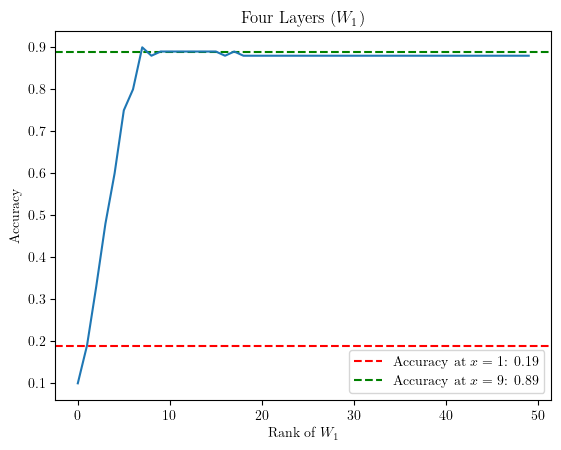

In [177]:
y_value_at_x1 = Testing_Accuracy[1]
plt.axhline(y=y_value_at_x1, color='r', linestyle='--', label=fr"Accuracy at $x=1$: {y_value_at_x1:.2f}")
y_value_at_x2 = Testing_Accuracy[9]
plt.axhline(y=y_value_at_x2, color='g', linestyle='--', label=fr"Accuracy at $x=9$: {y_value_at_x2:.2f}")
plt.plot(range_s, Testing_Accuracy)
plt.xlabel(fr"Rank of $W_1$")
plt.ylabel(r"Accuracy")
plt.title(fr"Four Layers ($W_1$)")
plt.legend()
plt.savefig(f"rank_accuracy_{no_nodes[1]}x{no_nodes[2]}.pdf", bbox_inches='tight')
plt.show()
plt.close()

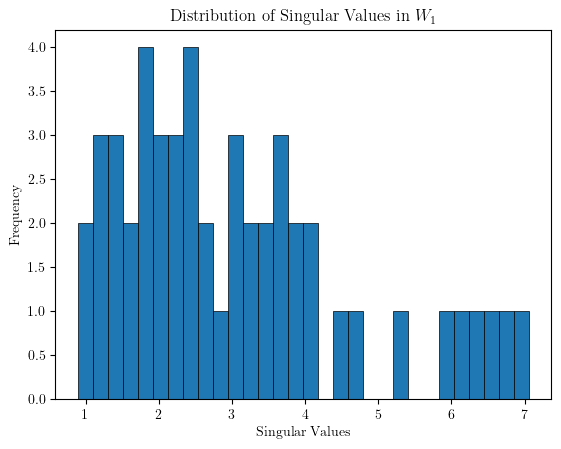

In [178]:
plt.figure()
plt.hist(S, bins=30, edgecolor='black', linewidth=0.5)
plt.xlabel(r"Singular Values")
plt.ylabel(r"Frequency")
plt.title(fr"Distribution of Singular Values in $W_1$")
plt.savefig(f"singval_hist_{no_nodes[1]}x{no_nodes[2]}1.pdf", bbox_inches='tight')
plt.show()
plt.close()

(50, 50)
min eigvec: 4.002013027559815e-07
max eigvec: 0.16712987130995757
mean eigvec: 0.02
std eigvec: 0.02662066911383027


KS Statistic: 0.09555555555555556
P-value: 0.032796328503363684
Reject the null (different distribution)


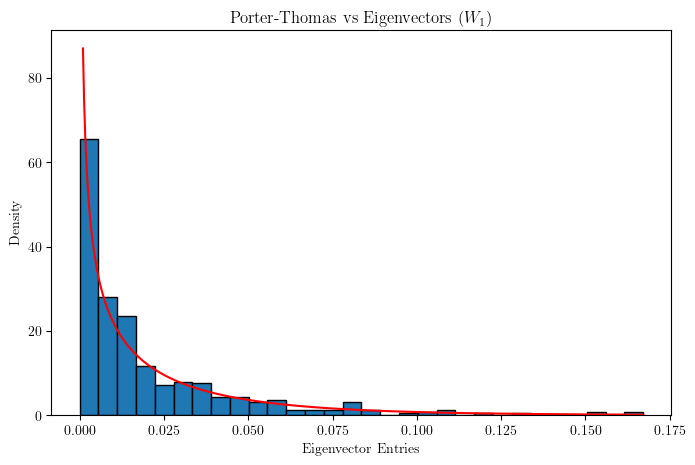

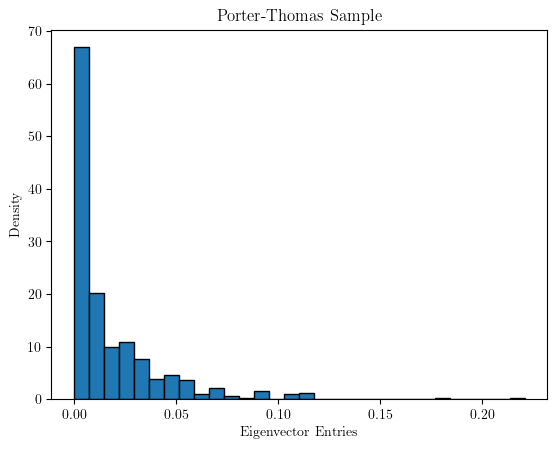

In [179]:
# 
from scipy.stats import ks_2samp

# This is the number of rows and columns in the matrix
k_m = no_nodes[k]
k_n = no_nodes[k + 1]

wish = W[k].copy().T @ W[k].copy()
print(wish.shape)
eigvalues, eigvecs = np.linalg.eigh(wish)
eigvec_collection = (eigvecs[:, 1:10].copy()).flatten()
eigvec = ((eigvec_collection)**2)
# eigvec = ((eigvecs[:, 0].copy()/np.linalg.norm(eigvecs[:,0]))**2)
print(f"min eigvec: {np.min(eigvec)}")
print(f"max eigvec: {np.max(eigvec)}")
print(f"mean eigvec: {np.mean(eigvec)}")
print(f"std eigvec: {np.std(eigvec)}")

plt.figure(figsize=(8,5))

def pt_pdf(x):
    return (np.sqrt(k_n/(2*np.pi*x)))*np.exp((-k_n*x)/2)

z = np.linspace(0.001,np.max(eigvec), 500)
porter_thomas = pt_pdf(z)


# Now we will use Acceptance-Rejection Sampling to compare the two distributions
# We will sample from the Porter-Thomas distribution and compare it to the eigenvector distribution
length_eigvec = len(eigvec)
porter_thomas_sample = []
lambda_ = 1/np.mean(eigvec)

def exponen(x):
    return lambda_*np.exp(-lambda_*x)

upper_bound = np.max(pt_pdf(np.linspace(0.001,np.max(eigvec)))/exponen(np.linspace(0.001,np.max(eigvec))))

while len(porter_thomas_sample) < length_eigvec:
    u = np.random.uniform(0, 1)
    y = np.random.exponential(scale=1/lambda_)
    if u <= (pt_pdf(y)/(exponen(y)*upper_bound)):
        porter_thomas_sample.append(y)

stat, p_val = ks_2samp(porter_thomas_sample,eigvec)

print("\n")
print("KS Statistic:", stat)
print("P-value:", p_val)

if p_val > 0.05:
    print("Fail to reject the null (similar distributions)")
else:
    print("Reject the null (different distribution)")

# A comparison of the two distributions
plt.hist(eigvec, bins=30, edgecolor='black',density=True)
plt.plot(z, porter_thomas, 'r-')
plt.title(fr"Porter-Thomas vs Eigenvectors ($W_{k}$)")
plt.ylabel("Density")
plt.xlabel("Eigenvector Entries")
plt.show()

# Sample from the Porter-Thomas distribution
plt.hist(porter_thomas_sample, bins=30, edgecolor='black',density=True)
plt.title(f"Porter-Thomas Sample")
plt.ylabel("Density")
plt.xlabel("Eigenvector Entries")
plt.show()


In [180]:
plt.hist(eigvec, bins=30, edgecolor='black',density=True, label="Eigenvector Entries")
plt.plot(z, porter_thomas, 'r-', label="Porter-Thomas PDF")
plt.legend()
plt.title(fr"Porter-Thomas Density against Eigenvector Entries ($W_{k}$)")
plt.ylabel("Density")
plt.xlabel("Eigenvector Entries")
plt.savefig(f"port_thom_hist_{no_nodes[1]}x{no_nodes[2]}.pdf", bbox_inches='tight')
plt.close()

This is the graph used in the report.

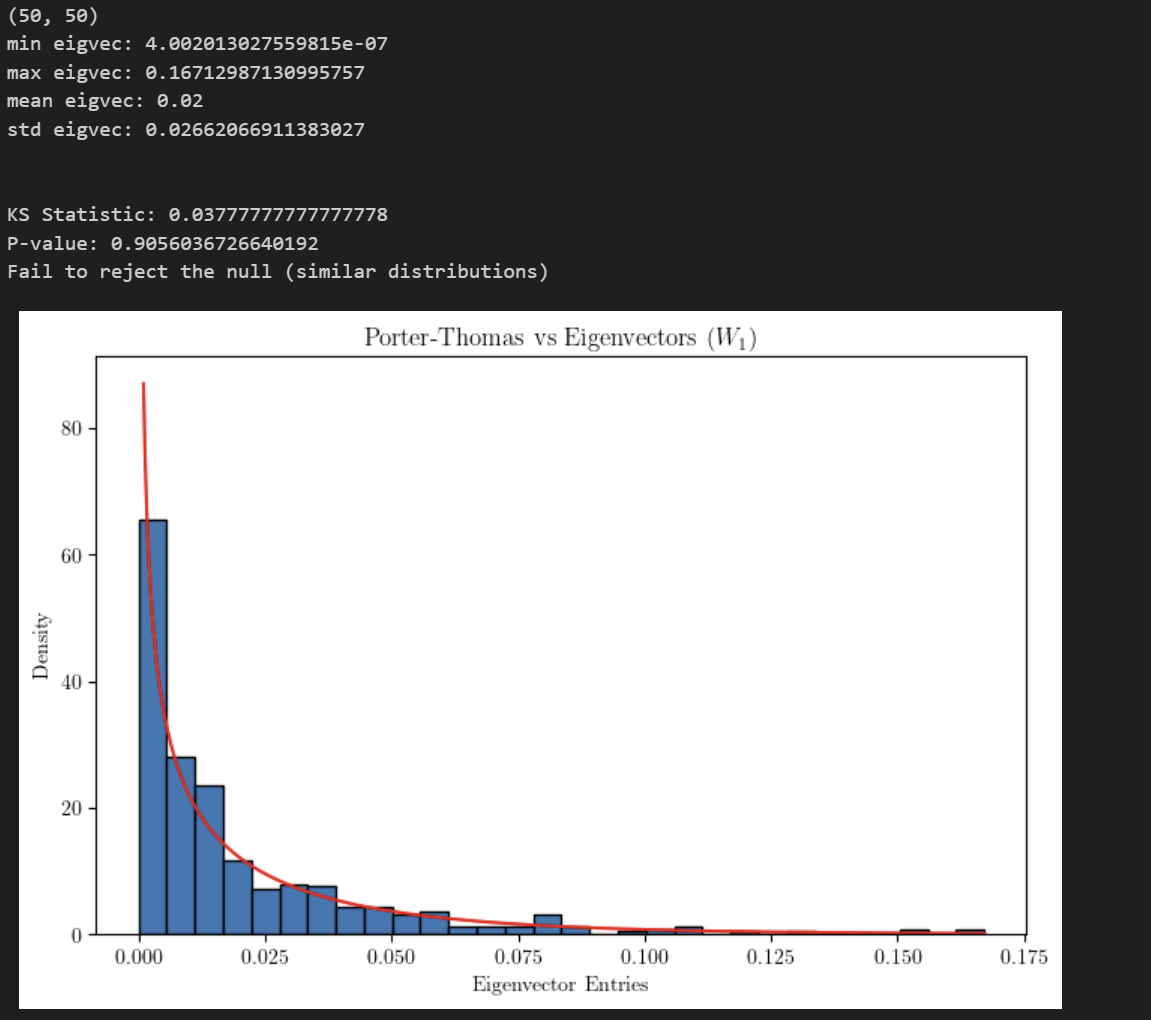

-0.0013579442660124393
0.3464334162955866
Length of eigenvalues: 50


KS Statistic: 0.195
P-value: 0.2616098760865728
Fail to reject the null (similar distributions)


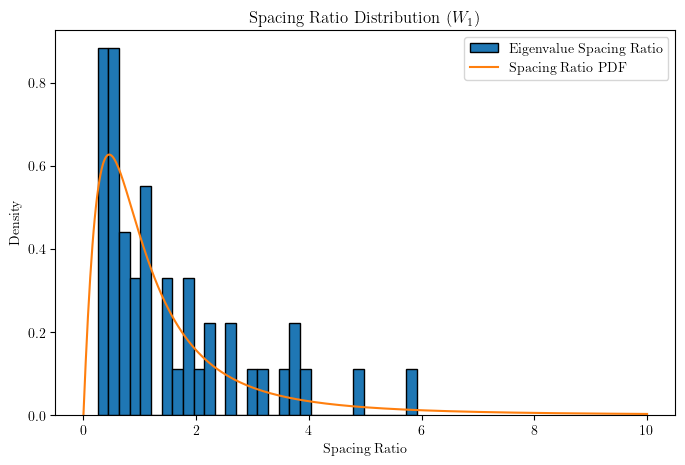

In [181]:
# Spacing Ratio distribution statistics
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ks_2samp

np.random.seed(42)
def spacing_ratio_pdf(x):
    return (27*(x + x**2))/(8*(1 + x + x**2)**(5/2))

z = np.linspace(0, 10, 500)

W_standard = (W[k].copy() - np.mean(W[k].copy())) / np.std(W[k].copy())
# W_1_srpdf = W[k].copy()
eigvalues_srpdf, eigvecs_srpdf = np.linalg.eigh(W_standard.T @ W_standard)
print(np.mean(W[k].copy()))
print(np.std(W[k].copy()))
spacing = [np.abs(eigvalues_srpdf[i+1] - eigvalues_srpdf[i]) for i in range(len(eigvalues_srpdf)-1)]
spacing_ratio = [spacing[i+1]/spacing[i] for i in range(len(spacing)-1)]

length_eigvals_srpdf = len(eigvalues_srpdf)
print(f"Length of eigenvalues: {length_eigvals_srpdf}")
lambda_srpdf = 1/np.mean(spacing_ratio)

def exponen(x):
    return lambda_srpdf*np.exp(-lambda_srpdf*x)

upper_bound_srpdf = np.max(spacing_ratio_pdf(np.linspace(0.001,np.max(spacing_ratio)))/exponen(np.linspace(0.001,np.max(spacing_ratio))))

spacing_ratio_sample = []

while len(spacing_ratio_sample) < length_eigvals_srpdf:
    u = np.random.uniform(0, 1)
    y = np.random.exponential(scale=1/lambda_srpdf)
    if u <= (spacing_ratio_pdf(y)/(exponen(y)*upper_bound_srpdf)):
        spacing_ratio_sample.append(y)


stat_srpdf, p_val_srpdf = ks_2samp(spacing_ratio_sample, spacing_ratio)
print("\n")
print("KS Statistic:", stat_srpdf)
print("P-value:", p_val_srpdf)
if p_val_srpdf > 0.05:
    print("Fail to reject the null (similar distributions)")
else:
    print("Reject the null (different distribution)")


plt.figure(figsize=(8,5))
plt.hist(spacing_ratio, bins=30, edgecolor='black', density=True, label="Eigenvalue Spacing Ratio")
plt.plot(z, spacing_ratio_pdf(z), label='Spacing Ratio PDF')
plt.title(fr"Spacing Ratio Distribution ($W_{k}$)")
plt.xlabel("Spacing Ratio")
plt.ylabel("Density")
plt.legend()
plt.savefig(f"spacing_ratio_hist_{no_nodes[1]}x{no_nodes[2]}.pdf", bbox_inches='tight')
plt.show()
plt.close()

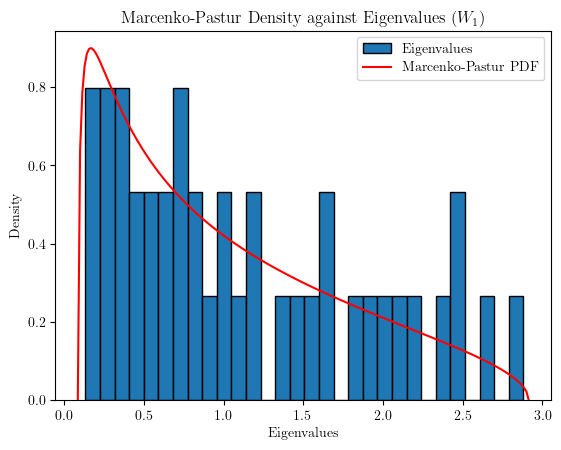

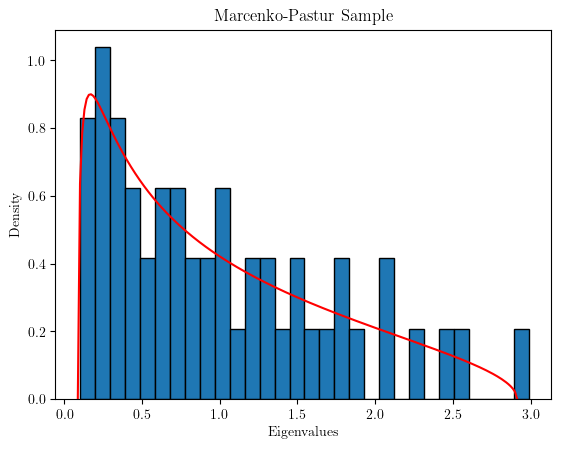

KS Statistic: 0.18608695652173912
P-value: 0.3253061815245993
Fail to reject the null (similar distributions)


In [182]:
# Marchenko-Pastur statistics
k_1 = 1
W_k_copy = W[k_1].copy()
W_k_norm = (W_k_copy - np.mean(W_k_copy))/(np.std(W_k_copy))

# This is the number of rows and columns in the matrix
k_1_m = no_nodes[k_1]
k_1_n = no_nodes[k_1 + 1]

S_matrix = (1/k_1_n)* W_k_norm.T @ W_k_norm

eigsvals, eigsvecs = np.linalg.eigh(S_matrix)
# print(eigsvals)
lambda_vals = np.linspace(min(eigsvals), max(eigsvals), 200)

aspectratio = k_1_n/k_1_m
lambdaplus = (1 + np.sqrt(aspectratio))**2
lambdaminus = (1 - np.sqrt(aspectratio))**2

def mp_pdf(x):
    return (1/(2*np.pi*aspectratio*x))*np.sqrt((lambdaplus - x)*(x - lambdaminus))

lambda_vals = np.linspace(lambdaminus, lambdaplus, 200)
marcenko_pastur = mp_pdf(lambda_vals)

plt.hist(eigsvals[:-9], bins=30, edgecolor='black',density=True, label="Eigenvalues")
plt.plot(lambda_vals, marcenko_pastur, 'r-', label="Marcenko-Pastur PDF")
plt.title(fr"Marcenko-Pastur Density against Eigenvalues ($W_{k_1}$)")
plt.ylabel(r"Density")
plt.xlabel(r"Eigenvalues")
plt.legend()
plt.show()

length_eigvals = len(eigsvals[:])
W_mat = np.random.normal(size=(k_1_m,k_1_n))
S = (1/k_1_m)*np.dot(W_mat.T, W_mat)
marcenko_pastur_sample = np.linalg.eigvals(S)
plt.hist(marcenko_pastur_sample, bins=30, edgecolor='black',density=True)
plt.plot(lambda_vals, marcenko_pastur, 'r-', label="Marcenko-Pastur PDF")
plt.title("Marcenko-Pastur Sample")
plt.ylabel("Density")
plt.xlabel("Eigenvalues")
plt.show()

stat, p_val = ks_2samp(marcenko_pastur_sample,eigsvals[:-4])

print("KS Statistic:", stat)
print("P-value:", p_val)

if p_val > 0.05:
    print("Fail to reject the null (similar distributions)")
else:
    print("Reject the null (different distribution)")

In [183]:
plt.hist(eigsvals[:-9], bins=30, edgecolor='black',density=True, label="Eigenvalues")
plt.plot(lambda_vals, marcenko_pastur, 'r-', label="Marcenko-Pastur PDF")
plt.title(fr"Marcenko-Pastur Density against Eigenvalues ($W_{k_1}$)")
plt.ylabel(r"Density")
plt.xlabel(r"Eigenvalues")
plt.legend()
plt.savefig(f"marc_past_hist_{no_nodes[1]}x{no_nodes[2]}.pdf", bbox_inches='tight')
plt.close()

In [184]:
print(W[1].shape)

(100, 50)


In the following, these are figures used in my report.

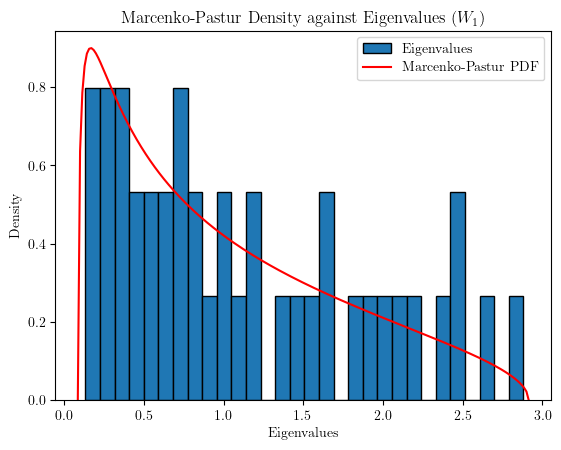

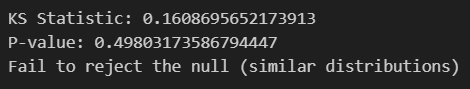

The code below is part of the collaborative work that was done with Greenman.

In [186]:
from scipy.io import loadmat

concatenatedW4 = loadmat('concatenated_W4.mat')
list = concatenatedW4["concatenated_W4"]
print(list.shape[2])

JPW4s = []

for i in range(list.shape[2]):
    JPW4s.append(list[:,:,i])

JPS4s = []
JPreducedrankW4s = []

for i in range(len(JPW4s)):
    U4,S4,VT4 = np.linalg.svd(JPW4s[i].copy())
    JPS4s.append(S4.copy())

    jp_red_rank_w4s = []
    for rank in range(101):
        S4_rank = S4.copy()
        S4_rank[rank:] = 0
        S4_rank = np.diag(S4_rank)
        W4_rank = U4 @ S4_rank @ VT4
        jp_red_rank_w4s.append(W4_rank.copy())

    JPreducedrankW4s.append(jp_red_rank_w4s.copy())

print(len(JPreducedrankW4s[0]))
print(JPreducedrankW4s[0][1].shape)
print(JPreducedrankW4s[0][2].shape)



from scipy.io import savemat

savemat('JPreducedrankW4s.mat', {'JPreducedrankW4s': JPreducedrankW4s})

   





40
101
(100, 100)
(100, 100)
